# Extending to a d-p model: Charge-transfer physics and double-counting

In this tutorial, we will extend our model of La$_{2}$CuO$_{4}$ beyond the single-band approximation by explicilty including the in-plane $2p_{x}$ and $2p_{y}$ orbitals from the oxygen, resulting in a three orbital $d$-$p$ model. This richer low-energy model allows us to captures essential aspects of **charge-transfer physics**, which plays a central role in the electronic structure of cuprate superconductors.

We will learn how to:
- Modify the embedding description (``Embedding``) to separate the Cu-$d_{x^{2}-y^{2}}$ from the oxygen and only solve the Cu-$d$ impurity.
- Introduce the **double-counting correction** to maintain the relative energy splitting between the Cu-$3d$ and O-$2p$ levels.
- Solve the impurity problem within DMFT and analyze how the spectral weight is distributed between the $d$ and $p$ orbitals.
- Investigate the effects of electronic **screening** and study the size of the **charge-transfer gap** in our model.

By the end of this tutorial, you will understand how to move beyond the single-band Hubbard model, handle double-counting corrections carefully, and analyze how the inclusion of ligand states qualitatively changes the low-energy electronic structure of correlated materials like La$_{2}$CuO$_{4}$.

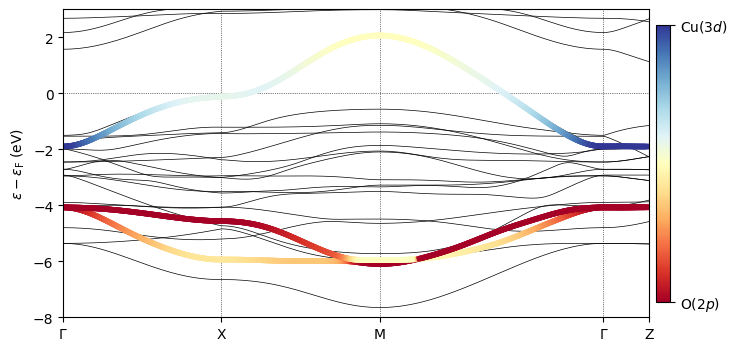

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors
eF = 12.7367
high_symm_points = [0.0000, 0.9342, 1.8683, 3.1894, 3.4595]
high_symm_labels = [r'$\Gamma$', 'X', 'M', r'$\Gamma$', 'Z']
fig, ax = plt.subplots(figsize=(9,4))
data = np.loadtxt('emery/lco_bands.dat.gnu')
kpts = np.unique(data[:,0])
bands = data[:,1].reshape(-1, len(kpts))

for b in range(len(bands)): ax.plot(kpts, bands[b,:]-eF, 'k-', lw=0.5)
ax.axhline(0.0, color='k', ls='dotted', lw=0.5)
for k in high_symm_points: ax.axvline(k, color='k', ls='dotted', lw=0.5)
ax.set_xticks(high_symm_points); ax.set_xticklabels(high_symm_labels)

w90_data = np.loadtxt(f'emery/lco_band_proj1.dat')
w90_kpts = np.unique(w90_data[:,0])
w90_bands = w90_data[:,1].reshape(-1, len(w90_kpts))
w90_weights = w90_data[:,2].reshape(-1, len(w90_kpts))
w90_weights /= np.max(w90_weights)
factor = kpts[-1]/w90_kpts[-1]
for b in range(len(w90_bands)):
    for ik in range(len(w90_bands[b,:])-2):
        data = ax.plot(w90_kpts[ik:ik+2]*factor, 
                      w90_bands[b,ik:ik+2]-eF, 
                       '-',
                       lw=4,
                      color=plt.get_cmap('RdYlBu')(w90_weights[b,ik])
                      )
ax.set_ylim(-8,3)
ax.set_xlim(min(high_symm_points), max(high_symm_points))
ax.set_ylabel(r'$\varepsilon-\varepsilon_{\mathrm{F}}$ (eV)')
cbar = fig.colorbar(cm.ScalarMappable(colors.Normalize(0,1), cmap='RdYlBu'), ax=ax, pad=0.01, shrink=0.9)
cbar.set_ticks([0,1]); cbar.set_ticklabels(['O($2p$)', r'Cu($3d$)'])
plt.show()

## The d-p model

Our goal is to repreoduce the results in X and Y. In these papers, a $d$-$p$ model is studied for La$_{2}$CuO$_{4}$. It is determined that the $d$-$p$ interactions are crucial to capturing the correct charge-transfer physics. Thus, we will solve the following model:

$$ H = H_{0} + H_{\mathrm{int}}, $$
where $H_{0}$ is the tight-binding Hamiltonian and $H_{\mathrm{int}}$ corresponds to

$$ H_{\mathrm{int}} = U_{dd} \sum_{i}n_{i\uparrow}n_{i\downarrow} + U_{pp}\sum_{j}n_{jp\uparrow}n_{jp\downarrow} + U_{pd}\sum_{\langle ij \rangle}n_{id}n_{jp},$$
where $n= n_{\uparrow} + n_{\downarrow}$. We will solve the $d$-$d$ interactions within DMFT using a CT-QMC solver, while the $p$-$p$ and $p$-$d$ interactions will be solved at the Hartree level.

$$ \begin{pmatrix} \Sigma_{dd} & &\\ & \Sigma_{pp} & \\ & & \Sigma_{pp} \end{pmatrix},$$
where $$ \begin{align} \Sigma_{dd} &= \Sigma_{\mathrm{imp}} - U_{dd}(n_{d} - \frac{1}{2}) + 4U_{pd}(n_{p} - n_{p}^{\mathrm{DFT}})\\
\Sigma_{pp} &= U_{pp}(n_{p}-n_{p}^{\mathrm{DFT}}) + 2U_{pd}(n_{d}-n_{d}^{\mathrm{DFT}}) \end{align}$$

In [9]:
import bzsummation as modest
target_density, obe = modest.one_body_elements_from_dft_converter('emery/lco_mod.h5')
print(obe)

One body elements representing a downfolding from (restricted) Bloch 𝓑 to Correlated space 𝓒 from DFT code [one_body_elements_on_grid]
  H:
    Band dispersion ε^σ(k) on a grid [band_dispersion]:
      Number of bands (max): 3
      Represented on a fixed grid of 343 points.
      Shape of H[k_idx, σ, ν, ν'] = [343, 1, 3, 3]
  C_space:
    Local space [orbital_set]:
      Total dimension [M]: 3
      Number of correlated atoms: 3
      Number of inequivalent correlated atoms = 2
      Atomic decomposition:
         dim_a:   1   1   1
             a:   0   1   2
        irreps: [1] [1] [1]
  P:
    Downfolding projector P^σ_mν(k) on a grid [downfolding_projector]:
      Shape of P[k_idx, σ, m, ν]  = [343, 1, 3, 3]
  IBZ = false



In [10]:
E = modest.make_embedding_with_equivalences(obe.C_space)
print(E)

Embedding:
  Spin index (σ/τ) names: ["up", "down"]

  Σ_embed block decomposition:
    dim_α:   1   1   1
        α:   0   1   2

  Impurities
    Block dimensions, dim_γ for all γ:
      [n_imp = 0] dim_γ =   1
                      γ =   0
      [n_imp = 1] dim_γ =   1
                      γ =   0
    Gf Block structures for solvers as names, [dim]:
      [imp_idx = 0] up_0 [1], down_0 [1]
      [imp_idx = 1] up_0 [1], down_0 [1]

  Mapping ψ(α,σ) = (imp_idx, γ, τ) 
             |          σ = 0 / up                    σ = 1 / down           
      -------+-------------------------------+------------------------------+
      α = 0  |   (imp_idx = 0, γ = 0, τ = 0)    (imp_idx = 0, γ = 0, τ = 1)  
      α = 1  |   (imp_idx = 1, γ = 0, τ = 0)    (imp_idx = 1, γ = 0, τ = 1)  
      α = 2  |   (imp_idx = 1, γ = 0, τ = 0)    (imp_idx = 1, γ = 0, τ = 1)  



In [68]:
E = E.drop(1)

In [69]:
from triqs.gf import MeshImFreq

beta = 10.0 # inverse temperature
mesh = MeshImFreq(beta, S='Fermion', n_iw=251) # Matsubara mesh

mu = modest.find_chemical_potential(target_density, obe, beta, verbosity=True)

gloc_C = modest.gloc(mesh, obe, mu)
print(gloc_C)

Green's Function  composed of 2 2-index blocks: 
 Greens Function ('0', 'up') with mesh Imaginary Freq Mesh with beta = 10, statistic = Fermion, n_iw = 251, positive_only = false and target_shape (3, 3): 
 
 Greens Function ('0', 'down') with mesh Imaginary Freq Mesh with beta = 10, statistic = Fermion, n_iw = 251, positive_only = false and target_shape (3, 3): 
 



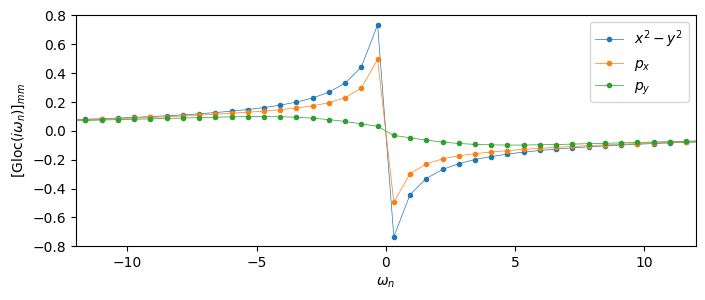

In [93]:
from triqs.plot.mpl_interface import oplot
fig, ax = plt.subplots(figsize=(8,3))
ax.oplot(gloc_C['0', 'up'][0,0].imag, 'o-', ms=3, lw=0.5, label=r'$x^{2}-y^{2}$')
ax.oplot(gloc_C['0', 'up'][1,1].imag, 'o-', ms=3, lw=0.5, label=r'$p_{x}$')
ax.oplot(gloc_C['0', 'up'][2,2].imag, 'o-', ms=3, lw=0.5, label=r'$p_{y}$')
ax.set_ylabel(r'[Gloc($i\omega_{n}$)]$_{mm}$')
ax.set_xlim(-12, 12); ax.set_ylim(-0.8, 0.8)
plt.show()

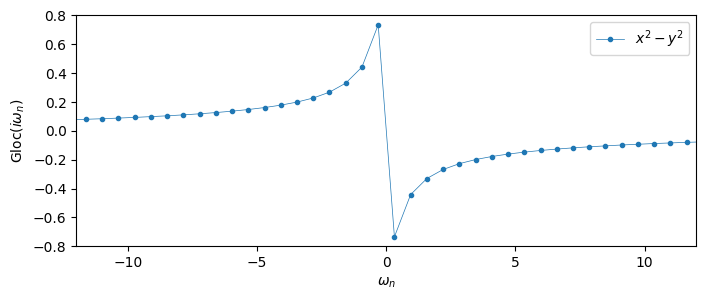

In [94]:
Gloc = E.extract(gloc_C)[0]

fig, ax = plt.subplots(figsize=(8,3))
ax.oplot(Gloc['up_0'][0,0].imag, 'o-', ms=3, lw=0.5, label=r'$x^{2}-y^{2}$')
ax.set_ylabel(r'Gloc($i\omega_{n}$)')
ax.set_xlim(-12, 12); ax.set_ylim(-0.8, 0.8)
plt.show()